In [ ]:
## 2026.08.18 using SeededNTM env
##            CODEX PDAC / Pancreas TMA from Michael_data_transfer/s1167
##            Metadata: s1167/raw_metadata_updated.xlsx  (Clinical_info sheet; do NOT use csv or s1167_metadata)
##            HE Zarr: s1167/{ACQUISITION_ID}/he_img/
##            Pancreas TMA = 473 cores (c001 148, c003 149, c005 95, c007 81)
##            cell-type CSV: 278 / 473 (c001 all; c003 130; c005/c007 none)
## 2026.08.27 analysis all 473 cores

In [2]:
# cd /home/lingyu/ssd2/Python/Hist2Pheno
# conda activate SeededNTM


In [11]:
## for AI edit
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

path = '/home/lingyu/ssd2/Python/'
import os
os.chdir(f'{path}Hist2Pheno/data/CODEX/HCC/')
!pwd

import sys
import importlib
import pandas as pd
from pathlib import Path

_pdac_dir = Path("/home/lingyu/ssd2/Python/Hist2Pheno/code/CODEX_pdac")
if str(_pdac_dir) not in sys.path:
    sys.path.insert(0, str(_pdac_dir))

import s1167_img_cell_mapping
importlib.reload(s1167_img_cell_mapping)
from s1167_img_cell_mapping import (
    DEFAULT_CODEX_DIR,
    DEFAULT_STARDIST_HE_DIR,
    DEFAULT_STARDIST_GIST_HE_DIR,
    DEFAULT_METADATA_FILE,
    S1167_SAMPLE,
    UNANNOTATED_LABEL,
    load_s1167_metadata,
    summarize_s1167_metadata,
    load_codex_he_alignment,
    load_s1167_celltype_hierarchy,
    load_s1167_celltypes,
    collect_celltypes_from_mapping,
    save_s1167_celltype_hierarchy,
    plot_he_overview,
    load_he_rgb,
    load_cells_by_acq,
    load_cells_from_mapping,
    cell_data_path,
    cell_types_path,
    pool_cells_by_coverslip,
    attach_coverslip,
    summarize_celltype_distributions,
    summarize_acquisitions,
    export_he_zarr_to_tif,
    copy_he_tifs,
    he_tif_path,
    export_codex_celltypes_on_he_jpg,
    export_codex_celltypes_to_jpg,
    preview_celltype_jpgs,
    has_codex_celltype_annotation,
)

import s1167_plot
importlib.reload(s1167_plot)
from s1167_plot import (
    PDAC_COVERSLIP_ORDER,
    GIST_COVERSLIP_ORDER,
    s1167_celltype_color_map,
    plot_celltype_proportions_stacked,
    plot_all_acq_celltype_distributions,
    plot_pooled_celltype_distribution,
)

CODEX_dir = str(DEFAULT_CODEX_DIR)
print("s1167_img_cell_mapping loaded from:", s1167_img_cell_mapping.__file__)
print("metadata file:", DEFAULT_METADATA_FILE)
print("s1167 root:", Path(CODEX_dir) / S1167_SAMPLE)


/nobackup2/users/lingyu/Python/Hist2Pheno/data/CODEX/HCC
s1167_img_cell_mapping loaded from: /nobackup2/users/lingyu/Python/Hist2Pheno/code/CODEX_pdac/s1167_img_cell_mapping.py
metadata file: raw_metadata_updated.xlsx
s1167 root: /nobackup2/users/lingyu/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167


## Load dataset

### Load s1167 metadata (`raw_metadata_updated.xlsx`, sheet `Clinical_info`)
Use the Excel file, **not** `raw_metadata.csv` and **not** sheet `s1167_metadata`. `tissue_type` in **Clinical_info** is the cohort label.

- **Pancreas TMA / PDAC**: 473 cores; cell-type CSV **278 / 473** (c005 and c007 have none).
- **GIST TMA**: 550 cores; cell-type CSV **550 / 550**.


In [4]:
## All 1023 cores from raw_metadata_updated.xlsx / Clinical_info
meta_all_df = load_s1167_metadata(
    base_dir=CODEX_dir, cohort=None, annotated_only=False,
)
summarize_s1167_metadata(meta_all_df, base_dir=CODEX_dir)

## Pancreas TMA / PDAC (473)
pdac_df = load_s1167_metadata(
    base_dir=CODEX_dir, cohort="PDAC", annotated_only=False,
)
pdac_ann_df = load_s1167_metadata(
    base_dir=CODEX_dir, cohort="PDAC", annotated_only=True,
)

## GIST TMA (550; all have cell-type CSV)
gist_df = load_s1167_metadata(
    base_dir=CODEX_dir, cohort="GIST TMA", annotated_only=False,
)
gist_ann_df = load_s1167_metadata(
    base_dir=CODEX_dir, cohort="GIST TMA", annotated_only=True,
)

print(f"\nPDAC cores: {len(pdac_df)}  with cell_types.csv: {len(pdac_ann_df)}")
print(pdac_df["prefix"].value_counts().to_string())
print(f"\nGIST cores: {len(gist_df)}  with cell_types.csv: {len(gist_ann_df)}")
print(gist_df["prefix"].value_counts().to_string())
display(pdac_ann_df.head())
display(gist_ann_df.head())


s1167 metadata: 1023 rows  (/nobackup2/users/lingyu/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167/raw_metadata.xlsx)

cohort × has_cell_types:
has_cell_types  False  True   All
cohort                           
GIST TMA            0   550   550
Pancreas TMA      195   278   473
All               195   828  1023

prefix × tissue_type:
tissue_type       GIST TMA  Pancreas TMA   All
prefix                                        
Charvill-94_c001         0           148   148
Charvill-94_c003         0           149   149
Charvill-94_c005         0            95    95
Charvill-94_c007         0            81    81
Charvill-94_c009       160             0   160
Charvill-94_c011       197             0   197
Charvill-94_c013       193             0   193
All                    550           473  1023

tissue_type (raw_metadata.xlsx):
tissue_type
GIST TMA        550
Pancreas TMA    473

HE zarr present: 1023/1023   cell_types.csv present: 828/1023

PDAC cores: 473  with cell_ty

,ACQUISITION_ID,SAMPLE_LABEL,SAMPLE_ID,tissue_type,tissue_subtype,diagnosis,tma_position,site,size,mitotic_rate,mutation_status,risk,primary,PATIENT_ID,species,treatment,prefix,cohort,tissue_type_filled
0,Charvill-94_c001_v001_r001_reg002,TA-237,NaN,Pancreas TMA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Charvill-94_c001,Pancreas TMA,Pancreas TMA
1,Charvill-94_c001_v001_r001_reg003,TA-237,NaN,Pancreas TMA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Charvill-94_c001,Pancreas TMA,Pancreas TMA
2,Charvill-94_c001_v001_r001_reg012,TA-237,NaN,Pancreas TMA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Charvill-94_c001,Pancreas TMA,Pancreas TMA
3,Charvill-94_c001_v001_r001_reg014,TA-237,NaN,Pancreas TMA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Charvill-94_c001,Pancreas TMA,Pancreas TMA
4,Charvill-94_c001_v001_r001_reg026,TA-237,NaN,Pancreas TMA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Charvill-94_c001,Pancreas TMA,Pancreas TMA


,ACQUISITION_ID,SAMPLE_LABEL,SAMPLE_ID,tissue_type,tissue_subtype,diagnosis,tma_position,site,size,mitotic_rate,mutation_status,risk,primary,PATIENT_ID,species,treatment,prefix,cohort,tissue_type_filled
0,Charvill-94_c011_v001_r001_reg002,TA-429A_2,31016.0,GIST TMA,NaN,NaN,4_8_13,liver - right lobe,NaN,NaN,KIT 11,malignant,met (primary unknown),13489.0,human,NaN,Charvill-94_c011,GIST TMA,GIST TMA
1,Charvill-94_c011_v001_r001_reg003,TA-429A_3,31017.0,GIST TMA,NaN,NaN,4_8_12,liver - right lobe,NaN,NaN,KIT 11,malignant,met (primary unknown),13489.0,human,NaN,Charvill-94_c011,GIST TMA,GIST TMA
2,Charvill-94_c011_v001_r001_reg004,TA-429A_4,31018.0,GIST TMA,NaN,NaN,4_8_11,Stomach,NaN,NaN,PDGFRA 18,malignant,primary,13490.0,human,NaN,Charvill-94_c011,GIST TMA,GIST TMA
3,Charvill-94_c011_v001_r001_reg007,TA-429A_7,31025.0,GIST TMA,NaN,NaN,4_8_8,stomach and esophagus,NaN,NaN,Wildtype,malignant,primary,13493.0,human,NaN,Charvill-94_c011,GIST TMA,GIST TMA
4,Charvill-94_c011_v001_r001_reg010,TA-429A_10,31030.0,GIST TMA,NaN,NaN,4_8_5,small intestine,NaN,NaN,KIT 11,malignant,primary,13496.0,human,NaN,Charvill-94_c011,GIST TMA,GIST TMA


### Preview HE (Zarr inside the acquisition folder)
Demo cores: c001 Pancreas TMA and c013 GIST TMA (both have cell-type annotation).


HE Charvill-94_c001_v001_r001_reg001: shape=(3, 3632, 3632), dtype=uint8
HE RGB array: (3632, 3632, 3), value range [0, 255]
Saved: /nobackup2/users/lingyu/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167/Charvill-94_c001_v001_r001_reg001/figures/he_img_overview.jpg


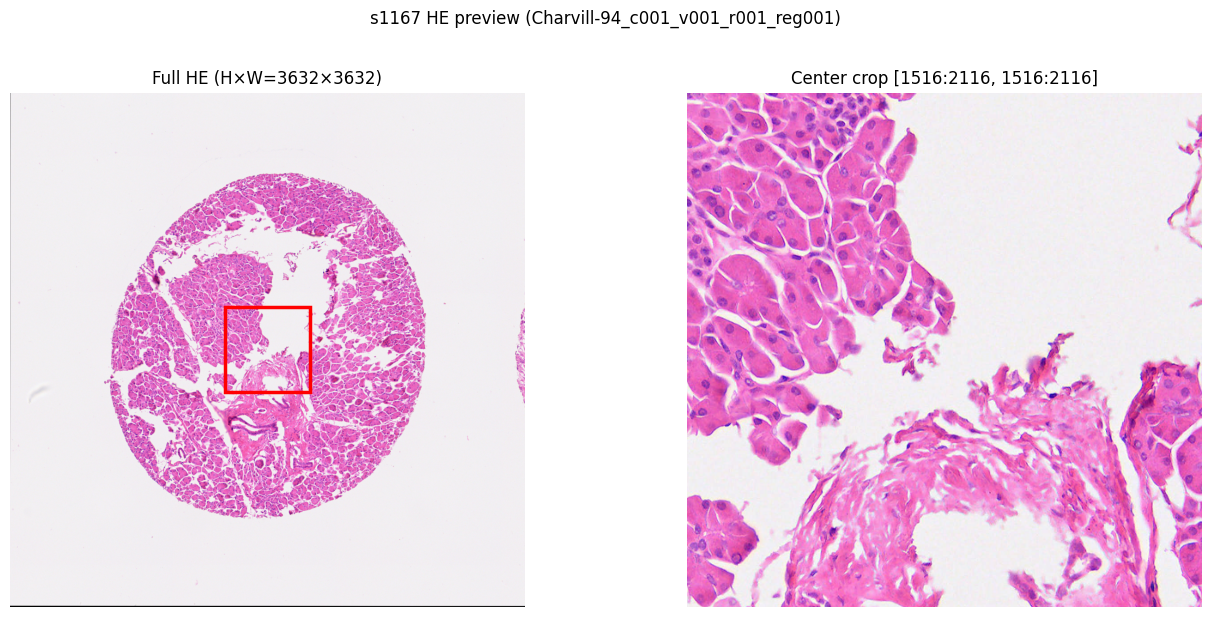

HE Charvill-94_c013_v001_r001_reg002: shape=(3, 2100, 2100), dtype=uint8
HE RGB array: (2100, 2100, 3), value range [0, 255]
Saved: /nobackup2/users/lingyu/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167/Charvill-94_c013_v001_r001_reg002/figures/he_img_overview.jpg


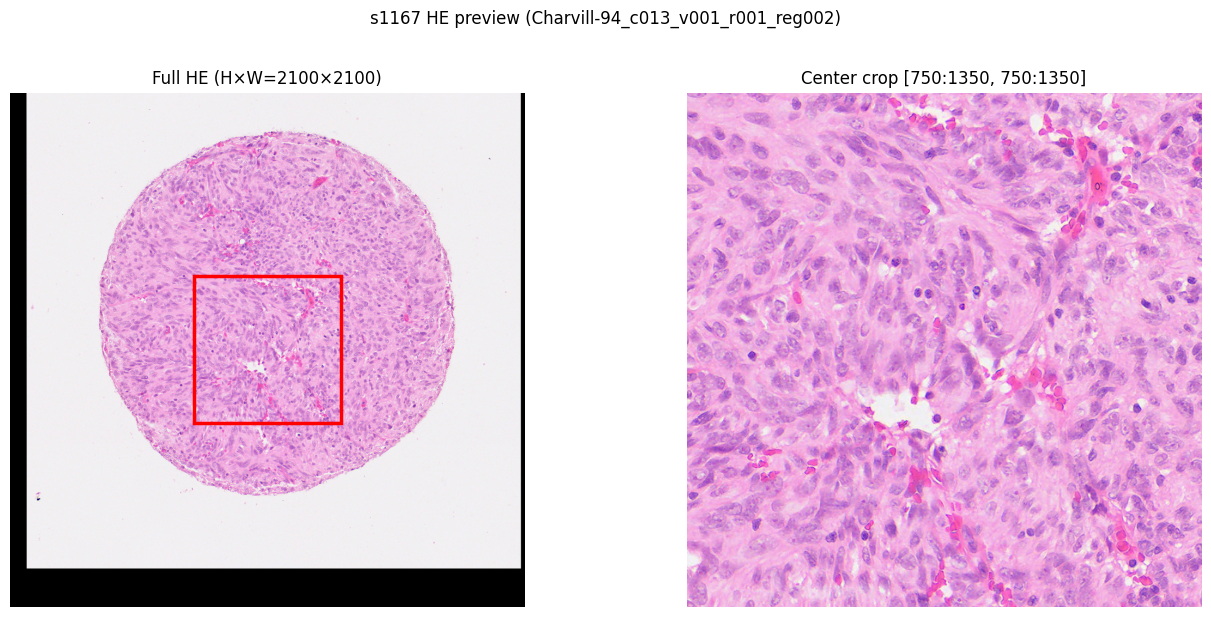

In [13]:
PRIMARY_ACQ_ID = 'Charvill-94_c001_v001_r001_reg001'          # Pancreas TMA
PRIMARY_GIST_ACQ_ID = 'Charvill-94_c013_v001_r001_reg002'     # GIST TMA
ACQ_IDS_ALSO_VIEW = []       # e.g. ['Charvill-94_c001_v001_r001_reg002']
GIST_ACQ_IDS_ALSO_VIEW = []  # e.g. ['Charvill-94_c013_v001_r001_reg003']

HE_PREVIEW_IDS = (
    [PRIMARY_ACQ_ID] + list(ACQ_IDS_ALSO_VIEW)
    + [PRIMARY_GIST_ACQ_ID] + list(GIST_ACQ_IDS_ALSO_VIEW)
)

for acq_id in HE_PREVIEW_IDS:
    he_rgb, _ = plot_he_overview(acq_id, base_dir=CODEX_dir, crop_half=300)


### Load CODEX cells on HE
Requires `{acq}.cell_data.csv` plus `{acq}.cell_types.csv` (c001/c003) or `{acq}.{id}.cell_types.csv` (c013/GIST).
PDAC: c001 has annotation; c003 has 130/149; **c005 and c007 have none**.
GIST: all 550 cores have cell-type CSV.


In [7]:
## Pancreas TMA
print("PRIMARY (PDAC) has cell types:", has_codex_celltype_annotation(PRIMARY_ACQ_ID, base_dir=CODEX_dir))
cells_by_acq = load_cells_by_acq(
    PRIMARY_ACQ_ID, ACQ_IDS_ALSO_VIEW or None, base_dir=CODEX_dir,
)
cells = cells_by_acq[PRIMARY_ACQ_ID]
summarize_acquisitions(cells_by_acq, pdac_ann_df)
display(cells.head())

## GIST TMA
print("PRIMARY (GIST) has cell types:", has_codex_celltype_annotation(PRIMARY_GIST_ACQ_ID, base_dir=CODEX_dir))
gist_cells_by_acq = load_cells_by_acq(
    PRIMARY_GIST_ACQ_ID, GIST_ACQ_IDS_ALSO_VIEW or None, base_dir=CODEX_dir,
)
gist_cells = gist_cells_by_acq[PRIMARY_GIST_ACQ_ID]
summarize_acquisitions(gist_cells_by_acq, gist_ann_df)
display(gist_cells.head())


PRIMARY (PDAC) has cell types: True

=== Charvill-94_c001_v001_r001_reg001 (cohort=Pancreas TMA) — 6018 cells ===
  x_pix [669, 3627], y_pix [118, 3140]
celltype
Cytotoxic T cells              2916
Epithelial cells               1225
Plasma cells                    514
Fibroblasts                     509
Lymphatic Endothelial cells     356
Helper T cells                  188
Macrophages                     154
B cells                          84
Tregs                            28
Other                            26
Neutrophils                      10
Dendritic cells                   8


,CELL_ID,x_pix,y_pix,VALUE,celltype
0,1,3199,118,0,Fibroblasts
1,2,1941,574,2,Macrophages
2,3,2001,576,3,Cytotoxic T cells
3,4,1914,577,4,Lymphatic Endothelial cells
4,5,2035,577,3,Cytotoxic T cells


PRIMARY (GIST) has cell types: True

=== Charvill-94_c013_v001_r001_reg002 (cohort=GIST TMA) — 3488 cells ===
  x_pix [115, 1812], y_pix [164, 1640]
celltype
Tregs                1265
Fibroblasts          1245
Helper T cells        248
Other                 184
DCs                   161
Endothelial cells     127
Monocytes             122
Neutrophils           101
B cells                20
Epithelial cells       12
Stromal cells           2
T cells                 1


,CELL_ID,x_pix,y_pix,VALUE,celltype
0,1,1066,165,6,Other
1,2,1084,164,1,Tregs
2,3,1041,167,3,Endothelial cells
3,4,1106,168,1,Tregs
4,5,1182,169,6,Other


### Export HE Zarr → TIFF
Saved as `s1167/{ACQUISITION_ID}/figures/{ACQUISITION_ID}.tif`.
1:1 from `he_img` (no downsample / upsample). Default: demo core only.


In [8]:
## Demo TIFF — Pancreas TMA
he_tif_paths = [
    export_he_zarr_to_tif(PRIMARY_ACQ_ID, base_dir=CODEX_dir, skip_if_exists=True)
]
print(f"Demo TIFF (PDAC): {he_tif_paths[0]}")

## Demo TIFF — GIST TMA
he_tif_paths_gist = [
    export_he_zarr_to_tif(PRIMARY_GIST_ACQ_ID, base_dir=CODEX_dir, skip_if_exists=True)
]
print(f"Demo TIFF (GIST): {he_tif_paths_gist[0]}")


SKIP (exists): /nobackup2/users/lingyu/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167/Charvill-94_c001_v001_r001_reg001/figures/Charvill-94_c001_v001_r001_reg001.tif
Demo TIFF (PDAC): /nobackup2/users/lingyu/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167/Charvill-94_c001_v001_r001_reg001/figures/Charvill-94_c001_v001_r001_reg001.tif
SKIP (exists): /nobackup2/users/lingyu/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167/Charvill-94_c013_v001_r001_reg002/figures/Charvill-94_c013_v001_r001_reg002.tif
Demo TIFF (GIST): /nobackup2/users/lingyu/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167/Charvill-94_c013_v001_r001_reg002/figures/Charvill-94_c013_v001_r001_reg002.tif


In [ ]:
# ## Batch: all Pancreas TMA HE (473)
# he_tif_paths = [
#     export_he_zarr_to_tif(aid, base_dir=CODEX_dir, skip_if_exists=True)
#     for aid in pdac_df["ACQUISITION_ID"]
# ]
# print(f"PDAC TIFFs: {len(he_tif_paths)}")

# ## Batch: all GIST TMA HE (550)
# he_tif_paths_gist = [
#     export_he_zarr_to_tif(aid, base_dir=CODEX_dir, skip_if_exists=True)
#     for aid in gist_df["ACQUISITION_ID"]
# ]
# print(f"GIST TIFFs: {len(he_tif_paths_gist)}")


SKIP (exists): /nobackup2/users/lingyu/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167/Charvill-94_c007_v001_r001_reg001/figures/Charvill-94_c007_v001_r001_reg001.tif
SKIP (exists): /nobackup2/users/lingyu/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167/Charvill-94_c007_v001_r001_reg002/figures/Charvill-94_c007_v001_r001_reg002.tif
SKIP (exists): /nobackup2/users/lingyu/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167/Charvill-94_c007_v001_r001_reg017/figures/Charvill-94_c007_v001_r001_reg017.tif
SKIP (exists): /nobackup2/users/lingyu/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167/Charvill-94_c007_v001_r001_reg024/figures/Charvill-94_c007_v001_r001_reg024.tif
SKIP (exists): /nobackup2/users/lingyu/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167/Charvill-94_c007_v001_r001_reg025/figures/Charvill-94_c007_v001_r001_reg025.tif
SKIP (exists): /nobackup2/users/lingyu/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167/

In [10]:
# ## Copy Pancreas TMA TIFFs → StarDist_Segment_pdac/HE_images
# copy_stats = copy_he_tifs(
#     he_tif_paths,
#     dest_dir=DEFAULT_STARDIST_HE_DIR,
#     skip_if_exists=True,
# )
# print("PDAC dest:", DEFAULT_STARDIST_HE_DIR)
# list(Path(DEFAULT_STARDIST_HE_DIR).glob("*.tif"))[:5]

# ## Copy GIST TMA TIFFs → StarDist_Segment_gist/HE_images
# copy_stats_gist = copy_he_tifs(
#     he_tif_paths_gist,
#     dest_dir=DEFAULT_STARDIST_GIST_HE_DIR,
#     skip_if_exists=True,
# )
# print("GIST dest:", DEFAULT_STARDIST_GIST_HE_DIR)
# list(Path(DEFAULT_STARDIST_GIST_HE_DIR).glob("*.tif"))[:5]


SKIP (dest exists): /nobackup2/users/lingyu/Python/Hist2Pheno/data/CODEX/HCC/StarDist_Segment_pdac/HE_images/Charvill-94_c007_v001_r001_reg001.tif
SKIP (dest exists): /nobackup2/users/lingyu/Python/Hist2Pheno/data/CODEX/HCC/StarDist_Segment_pdac/HE_images/Charvill-94_c007_v001_r001_reg002.tif
SKIP (dest exists): /nobackup2/users/lingyu/Python/Hist2Pheno/data/CODEX/HCC/StarDist_Segment_pdac/HE_images/Charvill-94_c007_v001_r001_reg017.tif
SKIP (dest exists): /nobackup2/users/lingyu/Python/Hist2Pheno/data/CODEX/HCC/StarDist_Segment_pdac/HE_images/Charvill-94_c007_v001_r001_reg024.tif
SKIP (dest exists): /nobackup2/users/lingyu/Python/Hist2Pheno/data/CODEX/HCC/StarDist_Segment_pdac/HE_images/Charvill-94_c007_v001_r001_reg025.tif
SKIP (dest exists): /nobackup2/users/lingyu/Python/Hist2Pheno/data/CODEX/HCC/StarDist_Segment_pdac/HE_images/Charvill-94_c007_v001_r001_reg026.tif
SKIP (dest exists): /nobackup2/users/lingyu/Python/Hist2Pheno/data/CODEX/HCC/StarDist_Segment_pdac/HE_images/Charvill-

[PosixPath('/nobackup2/users/lingyu/Python/Hist2Pheno/data/CODEX/HCC/StarDist_Segment_gist/HE_images/Charvill-94_c013_v001_r001_reg069.tif'),
 PosixPath('/nobackup2/users/lingyu/Python/Hist2Pheno/data/CODEX/HCC/StarDist_Segment_gist/HE_images/Charvill-94_c009_v001_r001_reg053.tif'),
 PosixPath('/nobackup2/users/lingyu/Python/Hist2Pheno/data/CODEX/HCC/StarDist_Segment_gist/HE_images/Charvill-94_c011_v001_r001_reg029.tif'),
 PosixPath('/nobackup2/users/lingyu/Python/Hist2Pheno/data/CODEX/HCC/StarDist_Segment_gist/HE_images/Charvill-94_c013_v001_r001_reg089.tif'),
 PosixPath('/nobackup2/users/lingyu/Python/Hist2Pheno/data/CODEX/HCC/StarDist_Segment_gist/HE_images/Charvill-94_c013_v001_r001_reg121.tif')]

### CODEX cell types on HE → JPG
Saved as `s1167/{ACQUISITION_ID}/figures/{ACQUISITION_ID}_celltype_on_HE.jpg`.


In [11]:
## Demo JPG (show=True in notebook)
jpg_path = export_codex_celltypes_on_he_jpg(
    PRIMARY_ACQ_ID,
    base_dir=CODEX_dir,
    skip_if_exists=True,
    show=True,
)
print("JPG:", jpg_path)

SKIP (exists): /nobackup2/users/lingyu/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167/Charvill-94_c001_v001_r001_reg001/figures/Charvill-94_c001_v001_r001_reg001_celltype_on_HE.jpg
JPG: /nobackup2/users/lingyu/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167/Charvill-94_c001_v001_r001_reg001/figures/Charvill-94_c001_v001_r001_reg001_celltype_on_HE.jpg


Displayed (existing): /nobackup2/users/lingyu/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167/Charvill-94_c001_v001_r001_reg001/figures/Charvill-94_c001_v001_r001_reg001_celltype_on_HE.jpg


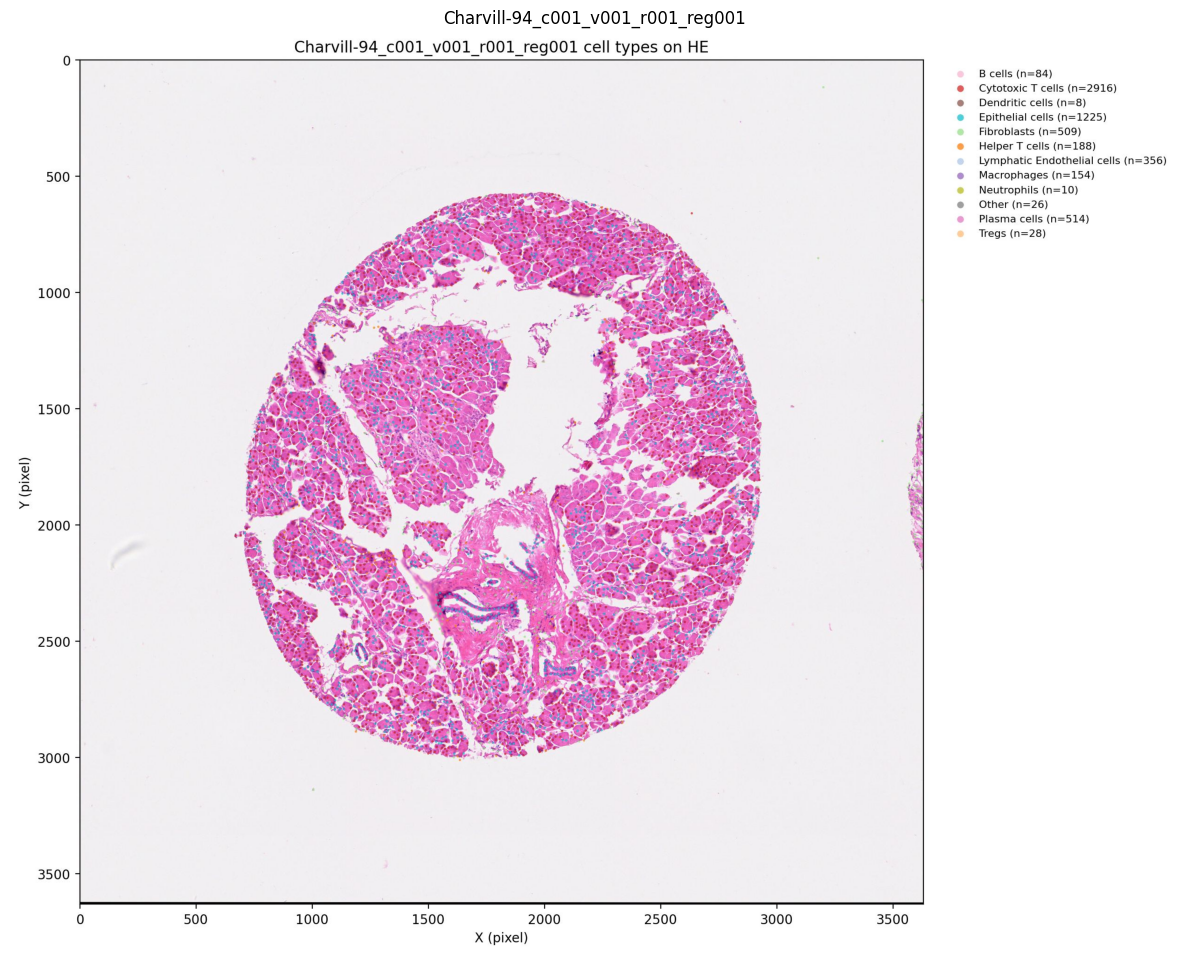

[PosixPath('/nobackup2/users/lingyu/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167/Charvill-94_c001_v001_r001_reg001/figures/Charvill-94_c001_v001_r001_reg001_celltype_on_HE.jpg')]

In [17]:
## Preview saved cell-type JPGs (demo + optional extras)
preview_celltype_jpgs(
    pdac_ann_df,
    base_dir=CODEX_dir,
    acq_ids=[PRIMARY_ACQ_ID] + list(ACQ_IDS_ALSO_VIEW),
    show=True,
)

## Visualization
CODEX↔HE alignment analog, cell-type hierarchy, then PDAC / GIST composition plots.


### CODEX↔HE alignment analog + cell-type hierarchy
s1167 has no MATCHED_HE Excel. Analog of HCC `ALIGNED=='Y'`: every core has `he_img/`.
Analog of `Annotation=='Y'`: `{acq}.cell_types.csv` (or `{acq}.{id}.cell_types.csv`) exists.
Hierarchy source is `raw_metadata_updated.xlsx` sheet `Celltype` (`celltype_level2 → celltype_level1 → celltype_level0`).
The notebook saves a copy to `s1167/s1167_celltype_hierarchy.xlsx` (both cohorts, including `Other`).
Retained Level2 drops `Other`, same role as HCC `Unknown` / `Stroma Uncharacterized`.


In [2]:
## CODEX↔HE alignment analog (HE inside each acquisition folder)
## ALIGNED=='Y' analog: with_he_only  |  Annotation=='Y' analog: cell_types.csv
alignment_df = load_codex_he_alignment(base_dir=CODEX_dir, cohort="PDAC", annotated_only=False)
print("The number of CODEX↔HE alignment (PDAC):", alignment_df.shape)

alignment_Anno_df = load_codex_he_alignment(base_dir=CODEX_dir, cohort="PDAC", annotated_only=True)
print("The number of CODEX↔HE alignment with Annotation (PDAC):", alignment_Anno_df.shape)
display(alignment_Anno_df.head())

alignment_gist_df = load_codex_he_alignment(base_dir=CODEX_dir, cohort="GIST TMA", annotated_only=False)
alignment_gist_Anno_df = load_codex_he_alignment(base_dir=CODEX_dir, cohort="GIST TMA", annotated_only=True)
print("The number of CODEX↔HE alignment (GIST):", alignment_gist_df.shape)
print("The number of CODEX↔HE alignment with Annotation (GIST):", alignment_gist_Anno_df.shape)


The number of CODEX↔HE alignment (PDAC): (473, 19)
The number of CODEX↔HE alignment with Annotation (PDAC): (278, 19)


,ACQUISITION_ID,SAMPLE_LABEL,SAMPLE_ID,tissue_type,tissue_subtype,diagnosis,tma_position,site,size,mitotic_rate,mutation_status,risk,primary,PATIENT_ID,species,treatment,prefix,cohort,tissue_type_filled
0,Charvill-94_c001_v001_r001_reg002,TA-237,NaN,Pancreas TMA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Charvill-94_c001,Pancreas TMA,Pancreas TMA
1,Charvill-94_c001_v001_r001_reg003,TA-237,NaN,Pancreas TMA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Charvill-94_c001,Pancreas TMA,Pancreas TMA
2,Charvill-94_c001_v001_r001_reg012,TA-237,NaN,Pancreas TMA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Charvill-94_c001,Pancreas TMA,Pancreas TMA
3,Charvill-94_c001_v001_r001_reg014,TA-237,NaN,Pancreas TMA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Charvill-94_c001,Pancreas TMA,Pancreas TMA
4,Charvill-94_c001_v001_r001_reg026,TA-237,NaN,Pancreas TMA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Charvill-94_c001,Pancreas TMA,Pancreas TMA


The number of CODEX↔HE alignment (GIST): (550, 19)
The number of CODEX↔HE alignment with Annotation (GIST): (550, 19)


In [3]:
## Hist2Pheno hierarchy: celltype_level2 → celltype_level1 → celltype_level0
## Source: raw_metadata_updated.xlsx / Celltype
## Save:   s1167/s1167_celltype_hierarchy.xlsx  (PDAC + GIST, including Other)
hierarchy_xlsx, hierarchy_all_df = save_s1167_celltype_hierarchy(base_dir=CODEX_dir)
print("Saved cell-type hierarchy:", hierarchy_xlsx)
print(hierarchy_all_df.groupby("cohort")["celltype_level2"].count().rename("n_level2").to_string())
display(hierarchy_all_df)

PDAC_CELLTYPES = load_s1167_celltypes(base_dir=CODEX_dir, cohort="PDAC", celltype_filter=["Other"])
print(f"PDAC cell types retained: {len(PDAC_CELLTYPES)}")
print(PDAC_CELLTYPES)

celltype_hierarchy_df = load_s1167_celltype_hierarchy(base_dir=CODEX_dir, cohort="PDAC", celltype_filter=["Other"])
print("The number of retained hierarchy cell types (PDAC):", len(celltype_hierarchy_df))
print(celltype_hierarchy_df.nunique().rename("n_classes").to_string())
display(celltype_hierarchy_df)

if set(PDAC_CELLTYPES) != set(celltype_hierarchy_df["celltype_level2"]):
    raise ValueError("PDAC_CELLTYPES and celltype hierarchy Level2 labels do not match")

observed_pdac = collect_celltypes_from_mapping(alignment_Anno_df, base_dir=CODEX_dir)
if set(PDAC_CELLTYPES) != set(observed_pdac):
    raise ValueError(
        "PDAC hierarchy Level2 and on-disk ANNOTATION_LABEL disagree: "
        f"excel_only={sorted(set(PDAC_CELLTYPES) - set(observed_pdac))} "
        f"disk_only={sorted(set(observed_pdac) - set(PDAC_CELLTYPES))}"
    )

GIST_CELLTYPES = load_s1167_celltypes(base_dir=CODEX_dir, cohort="GIST TMA", celltype_filter=["Other"])
gist_hierarchy_df = load_s1167_celltype_hierarchy(base_dir=CODEX_dir, cohort="GIST TMA", celltype_filter=["Other"])
print(f"\nGIST cell types retained: {len(GIST_CELLTYPES)}")
print(GIST_CELLTYPES)
display(gist_hierarchy_df)

if set(GIST_CELLTYPES) != set(gist_hierarchy_df["celltype_level2"]):
    raise ValueError("GIST_CELLTYPES and celltype hierarchy Level2 labels do not match")

observed_gist = collect_celltypes_from_mapping(alignment_gist_Anno_df, base_dir=CODEX_dir)
if set(GIST_CELLTYPES) != set(observed_gist):
    raise ValueError(
        "GIST hierarchy Level2 and on-disk ANNOTATION_LABEL disagree: "
        f"excel_only={sorted(set(GIST_CELLTYPES) - set(observed_gist))} "
        f"disk_only={sorted(set(observed_gist) - set(GIST_CELLTYPES))}"
    )


Saved cell-type hierarchy: /nobackup2/users/lingyu/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167/s1167_celltype_hierarchy.xlsx
cohort
GIST TMA        12
Pancreas TMA    12


,cohort,celltype_level2,celltype_level1,celltype_level0
0,Pancreas TMA,Epithelial cells,Epithelial,Epithelial
1,Pancreas TMA,Fibroblasts,Stromal,Stromal
2,Pancreas TMA,Cytotoxic T cells,T cells,Immune
3,Pancreas TMA,Helper T cells,T cells,Immune
4,Pancreas TMA,Tregs,T cells,Immune
5,Pancreas TMA,Macrophages,Myeloid,Immune
6,Pancreas TMA,Neutrophils,Myeloid,Immune
7,Pancreas TMA,Dendritic cells,Myeloid,Immune
8,Pancreas TMA,B cells,B cells,Immune
9,Pancreas TMA,Plasma cells,B cells,Immune


PDAC cell types retained: 11
['Epithelial cells', 'Fibroblasts', 'Cytotoxic T cells', 'Helper T cells', 'Tregs', 'Macrophages', 'Neutrophils', 'Dendritic cells', 'B cells', 'Plasma cells', 'Lymphatic Endothelial cells']
The number of retained hierarchy cell types (PDAC): 11
cohort              1
celltype_level2    11
celltype_level1     6
celltype_level0     4


,cohort,celltype_level2,celltype_level1,celltype_level0
0,Pancreas TMA,Epithelial cells,Epithelial,Epithelial
1,Pancreas TMA,Fibroblasts,Stromal,Stromal
2,Pancreas TMA,Cytotoxic T cells,T cells,Immune
3,Pancreas TMA,Helper T cells,T cells,Immune
4,Pancreas TMA,Tregs,T cells,Immune
5,Pancreas TMA,Macrophages,Myeloid,Immune
6,Pancreas TMA,Neutrophils,Myeloid,Immune
7,Pancreas TMA,Dendritic cells,Myeloid,Immune
8,Pancreas TMA,B cells,B cells,Immune
9,Pancreas TMA,Plasma cells,B cells,Immune



GIST cell types retained: 11
['Epithelial cells', 'Fibroblasts', 'Stromal cells', 'Helper T cells', 'Tregs', 'T cells', 'Monocytes', 'Neutrophils', 'DCs', 'B cells', 'Endothelial cells']


,cohort,celltype_level2,celltype_level1,celltype_level0
0,GIST TMA,Epithelial cells,Epithelial,Epithelial
1,GIST TMA,Fibroblasts,Stromal,Stromal
2,GIST TMA,Stromal cells,Stromal,Stromal
3,GIST TMA,Helper T cells,T cells,Immune
4,GIST TMA,Tregs,T cells,Immune
5,GIST TMA,T cells,T cells,Immune
6,GIST TMA,Monocytes,Myeloid,Immune
7,GIST TMA,Neutrophils,Myeloid,Immune
8,GIST TMA,DCs,Myeloid,Immune
9,GIST TMA,B cells,B cells,Immune


In [4]:
## Load all PDAC (473) and GIST (550) cores
## PDAC: alignment_df, not alignment_Anno_df. c005/c007 and 19 c003 cores have no cell_types.csv → Unannotated.
alignment_df = attach_coverslip(alignment_df)
alignment_gist_df = attach_coverslip(alignment_gist_df)
alignment_Anno_df = attach_coverslip(alignment_Anno_df)
alignment_gist_Anno_df = attach_coverslip(alignment_gist_Anno_df)

pdac_cells_all = load_cells_from_mapping(
    alignment_df, base_dir=CODEX_dir, skip_missing_annotation=False,
)
gist_cells_all = load_cells_from_mapping(
    alignment_gist_df, base_dir=CODEX_dir, skip_missing_annotation=False,
)

## Disk check: same pair as c001  {acq}.cell_data.csv + {acq}.cell_types.csv
pdac_file_check = alignment_df[["ACQUISITION_ID", "coverslip"]].copy()
pdac_file_check["cell_data"] = [
    cell_data_path(aid, base_dir=CODEX_dir).is_file() for aid in pdac_file_check["ACQUISITION_ID"]
]
pdac_file_check["cell_types"] = [
    cell_types_path(aid, base_dir=CODEX_dir) is not None for aid in pdac_file_check["ACQUISITION_ID"]
]
print(pdac_file_check.groupby("coverslip")[["cell_data", "cell_types"]].sum().to_string())
print(
    f"PDAC cores: {len(pdac_file_check)}  "
    f"cell_data: {int(pdac_file_check.cell_data.sum())}  "
    f"cell_types: {int(pdac_file_check.cell_types.sum())}"
)

pdac_file_check["n_cells"] = [
    len(pdac_cells_all[str(aid)]) for aid in pdac_file_check["ACQUISITION_ID"]
]
pdac_file_check["n_cells_annotated"] = pdac_file_check["n_cells"].where(
    pdac_file_check["cell_types"], 0
)
pdac_cell_summary = (
    pdac_file_check.groupby("coverslip")
    .agg(
        n_cores=("ACQUISITION_ID", "size"),
        n_cells_all=("n_cells", "sum"),
        n_cores_annotated=("cell_types", "sum"),
        n_cells_annotated=("n_cells_annotated", "sum"),
    )
    .astype(int)
)
pdac_cell_summary.loc["_TOTAL_"] = pdac_cell_summary.sum()
print("\nPDAC cell counts (278 annotated vs 473 all):")
display(pdac_cell_summary)
print(
    f"278 annotated cores: {int(pdac_file_check['cell_types'].sum())} datasets, "
    f"{int(pdac_file_check['n_cells_annotated'].sum())} cells"
)
print(
    f"473 all cores: {len(pdac_file_check)} datasets, "
    f"{int(pdac_file_check['n_cells'].sum())} cells"
)

pdac_celltype_counts = summarize_celltype_distributions(
    pdac_cells_all, alignment_df, celltype_filter=["Other"], verbose=False,
)
print("PDAC celltype_counts.shape:", pdac_celltype_counts.shape)
print("Unannotated cores (no cell_types.csv):", sum(
    (df["celltype"] == UNANNOTATED_LABEL).all() for df in pdac_cells_all.values()
))
display(pdac_celltype_counts)

gist_celltype_counts = summarize_celltype_distributions(
    gist_cells_all, alignment_gist_df, celltype_filter=["Other"], verbose=False,
)
print("GIST celltype_counts.shape:", gist_celltype_counts.shape)
display(gist_celltype_counts)


  loaded 50/473 (skipped 0)
  loaded 100/473 (skipped 0)
  loaded 150/473 (skipped 0)
  loaded 200/473 (skipped 0)
  loaded 250/473 (skipped 0)
  loaded 300/473 (skipped 0)
  loaded 350/473 (skipped 0)
  loaded 400/473 (skipped 0)
  loaded 450/473 (skipped 0)
  loaded 473/473 (skipped 0)
Loaded 473 dataset(s), skipped 0
  loaded 50/550 (skipped 0)
  loaded 100/550 (skipped 0)
  loaded 150/550 (skipped 0)
  loaded 200/550 (skipped 0)
  loaded 250/550 (skipped 0)
  loaded 300/550 (skipped 0)
  loaded 350/550 (skipped 0)
  loaded 400/550 (skipped 0)
  loaded 450/550 (skipped 0)
  loaded 500/550 (skipped 0)
  loaded 550/550 (skipped 0)
Loaded 550 dataset(s), skipped 0
           cell_data  cell_types
coverslip                       
c001             148         148
c003             149         130
c005              95           0
c007              81           0
PDAC cores: 473  cell_data: 473  cell_types: 278

PDAC cell counts (278 annotated vs 473 all):


,n_cores,n_cells_all,n_cores_annotated,n_cells_annotated
coverslip,,,,
c001,148,815463,148,815463
c003,149,782272,130,689519
c005,95,630639,0,0
c007,81,439300,0,0
_TOTAL_,473,2667674,278,1504982


278 annotated cores: 278 datasets, 1504982 cells
473 all cores: 473 datasets, 2667674 cells

=== Summary: 473 datasets, 2556433 retained cells (excluded: Other) ===
PDAC celltype_counts.shape: (13, 473)
Unannotated cores (no cell_types.csv): 195


,Charvill-94_c007_v001_r001_reg001,Charvill-94_c007_v001_r001_reg002,Charvill-94_c007_v001_r001_reg017,Charvill-94_c007_v001_r001_reg024,Charvill-94_c007_v001_r001_reg025,Charvill-94_c007_v001_r001_reg026,Charvill-94_c007_v001_r001_reg046,Charvill-94_c007_v001_r001_reg048,Charvill-94_c007_v001_r001_reg049,Charvill-94_c007_v001_r001_reg050,...,Charvill-94_c001_v001_r001_reg035,Charvill-94_c003_v001_r001_reg120,Charvill-94_c003_v001_r001_reg122,Charvill-94_c003_v001_r001_reg123,Charvill-94_c003_v001_r001_reg124,Charvill-94_c003_v001_r001_reg125,Charvill-94_c003_v001_r001_reg126,Charvill-94_c003_v001_r001_reg127,Charvill-94_c003_v001_r001_reg129,Charvill-94_c003_v001_r001_reg132
celltype,,,,,,,,,,,,,,,,,,,,,
Unannotated,6189,3509,1776,762,5183,5802,5622,7876,7919,1254,...,0,0,0,0,0,0,0,0,0,3671
Epithelial cells,0,0,0,0,0,0,0,0,0,0,...,587,143,1481,11,88,189,1303,63,1660,0
Fibroblasts,0,0,0,0,0,0,0,0,0,0,...,2065,1069,406,802,1260,1239,257,924,360,0
Macrophages,0,0,0,0,0,0,0,0,0,0,...,982,470,531,382,763,967,515,560,708,0
Lymphatic Endothelial cells,0,0,0,0,0,0,0,0,0,0,...,592,280,491,312,282,692,515,202,614,0
Cytotoxic T cells,0,0,0,0,0,0,0,0,0,0,...,663,143,2654,142,83,166,2792,511,2990,0
Helper T cells,0,0,0,0,0,0,0,0,0,0,...,302,461,421,79,845,1056,1026,615,478,0
Plasma cells,0,0,0,0,0,0,0,0,0,0,...,24,260,127,11,56,284,56,148,18,0
Neutrophils,0,0,0,0,0,0,0,0,0,0,...,87,29,19,873,18,506,21,468,22,0



=== Summary: 550 datasets, 1785460 retained cells (excluded: Other) ===
GIST celltype_counts.shape: (12, 550)


,Charvill-94_c011_v001_r001_reg002,Charvill-94_c011_v001_r001_reg003,Charvill-94_c011_v001_r001_reg004,Charvill-94_c011_v001_r001_reg007,Charvill-94_c011_v001_r001_reg010,Charvill-94_c011_v001_r001_reg011,Charvill-94_c011_v001_r001_reg012,Charvill-94_c011_v001_r001_reg014,Charvill-94_c011_v001_r001_reg016,Charvill-94_c011_v001_r001_reg026,...,Charvill-94_c011_v001_r001_reg086,Charvill-94_c011_v001_r001_reg087,Charvill-94_c011_v001_r001_reg088,Charvill-94_c011_v001_r001_reg089,Charvill-94_c011_v001_r001_reg090,Charvill-94_c011_v001_r001_reg091,Charvill-94_c011_v001_r001_reg092,Charvill-94_c011_v001_r001_reg093,Charvill-94_c011_v001_r001_reg094,Charvill-94_c011_v001_r001_reg095
celltype,,,,,,,,,,,,,,,,,,,,,
Fibroblasts,1101,1089,456,516,479,557,626,3,1329,1383,...,729,680,670,1277,9,979,1160,952,364,703
Helper T cells,393,415,142,12,452,459,151,4,88,713,...,360,91,96,27,11,27,36,201,60,69
Tregs,243,237,344,654,562,457,801,6,1146,787,...,426,253,544,925,8,1102,866,273,251,679
DCs,242,125,98,65,163,148,210,1,80,420,...,129,2085,1874,133,1,59,175,320,39,167
Monocytes,181,256,159,97,341,262,229,9,186,452,...,112,383,317,266,17,537,323,92,100,109
Endothelial cells,147,145,104,32,95,119,59,1,74,106,...,87,44,90,76,9,96,105,76,109,121
Neutrophils,21,19,38,78,83,64,33,2,97,64,...,90,135,124,83,5,85,57,54,45,89
Epithelial cells,11,16,2,9,3,5,4,563,8,12,...,1,15,19,8,817,10,4,4,2,8
B cells,5,5,25,2,8,12,2,0,24,4,...,5,5,5,4,0,6,10,0,4,7


In [8]:
pdac_counts_anno

,Charvill-94_c001_v001_r001_reg002,Charvill-94_c001_v001_r001_reg003,Charvill-94_c001_v001_r001_reg012,Charvill-94_c001_v001_r001_reg014,Charvill-94_c001_v001_r001_reg026,Charvill-94_c001_v001_r001_reg029,Charvill-94_c001_v001_r001_reg037,Charvill-94_c001_v001_r001_reg047,Charvill-94_c001_v001_r001_reg058,Charvill-94_c001_v001_r001_reg065,...,Charvill-94_c003_v001_r001_reg128,Charvill-94_c001_v001_r001_reg035,Charvill-94_c003_v001_r001_reg120,Charvill-94_c003_v001_r001_reg122,Charvill-94_c003_v001_r001_reg123,Charvill-94_c003_v001_r001_reg124,Charvill-94_c003_v001_r001_reg125,Charvill-94_c003_v001_r001_reg126,Charvill-94_c003_v001_r001_reg127,Charvill-94_c003_v001_r001_reg129
celltype,,,,,,,,,,,,,,,,,,,,,
Epithelial cells,1932,938,741,1100,541,3066,200,253,2576,534,...,16,587,143,1481,11,88,189,1303,63,1660
Fibroblasts,1832,1120,1480,868,1157,702,866,760,685,681,...,1330,2065,1069,406,802,1260,1239,257,924,360
Macrophages,397,600,592,369,507,1755,337,265,1261,329,...,428,982,470,531,382,763,967,515,560,708
Lymphatic Endothelial cells,194,346,536,66,245,518,87,320,665,435,...,219,592,280,491,312,282,692,515,202,614
Cytotoxic T cells,189,66,541,217,107,159,167,32,1503,43,...,309,663,143,2654,142,83,166,2792,511,2990
Helper T cells,108,474,444,66,365,2511,251,156,944,321,...,344,302,461,421,79,845,1056,1026,615,478
Plasma cells,35,88,91,29,66,315,197,39,776,45,...,75,24,260,127,11,56,284,56,148,18
Neutrophils,28,93,36,768,25,454,19,11,723,12,...,10,87,29,19,873,18,506,21,468,22
Tregs,17,4,14,4,3,21,3,0,20,6,...,4,6,1,35,2,2,5,11,5,7


PDAC stacked cores: 278
Saved: /nobackup2/users/lingyu/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167/Results/figures/s1167_pdac_celltype_proportions_stacked.pdf


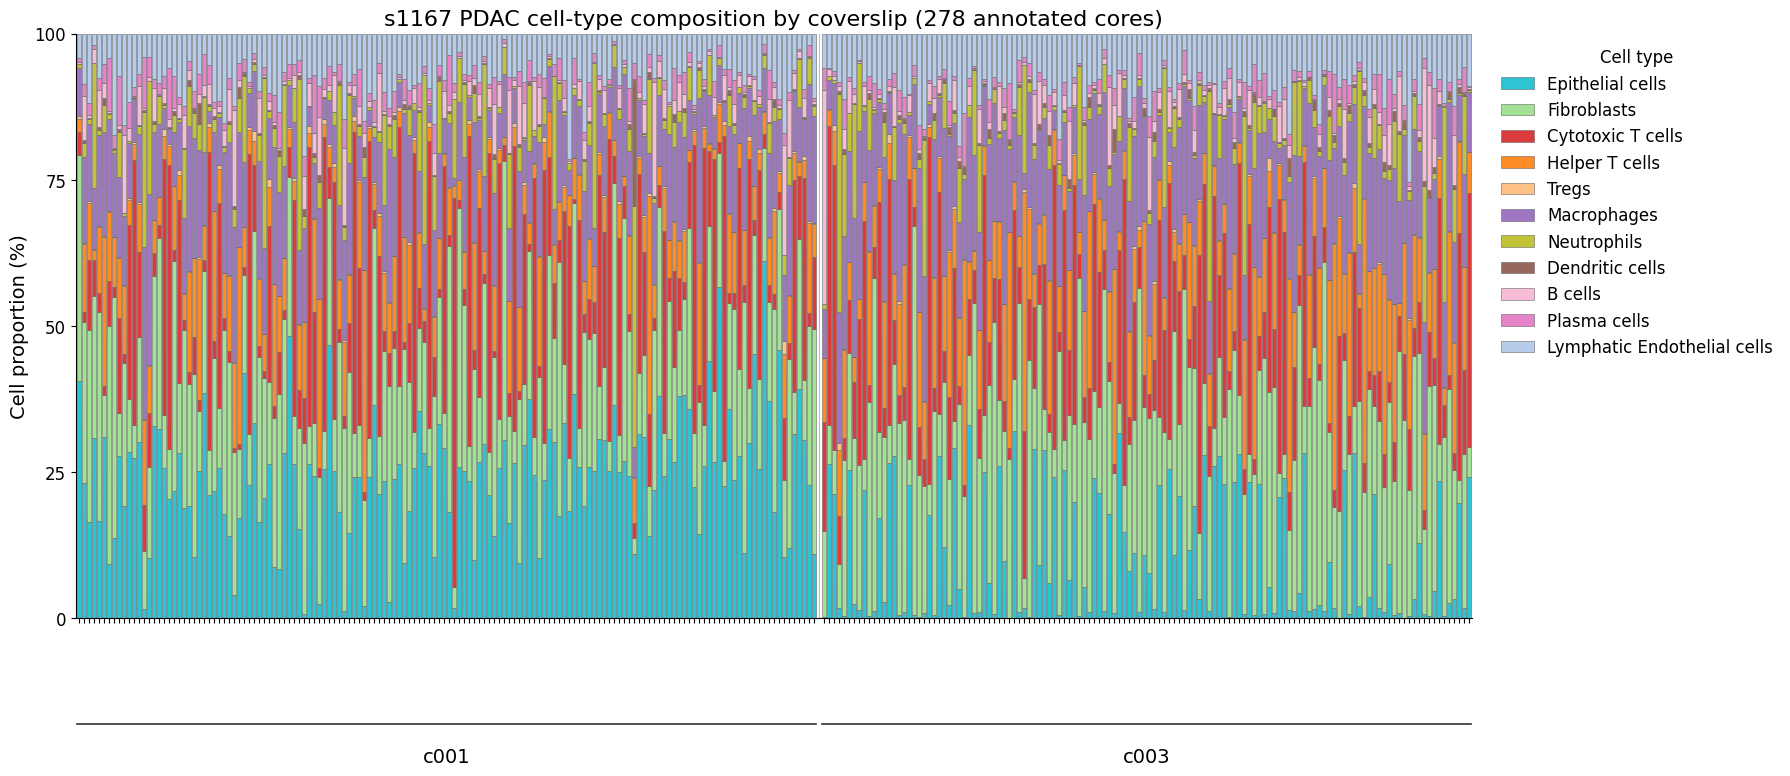

In [ ]:
figure_save_path = Path(CODEX_dir) / S1167_SAMPLE / "Results" / "figures"

## Grey bars are not a plotting bug.
## Cores without cell_types.csv were labeled Unannotated (c003: 19; c005: 95; c007: 81).
## Stacked composition uses annotated cores only (278), analog of HCC Annotation=='Y'.
PDAC_COLORS = s1167_celltype_color_map(PDAC_CELLTYPES)
GIST_COLORS = s1167_celltype_color_map(GIST_CELLTYPES)

pdac_counts_anno = pdac_celltype_counts.drop(index=[UNANNOTATED_LABEL], errors="ignore")    # UNANNOTATED_LABEL = "Unannotated"
pdac_keep = pdac_counts_anno.drop(index="_TOTAL_", errors="ignore").sum(axis=0) > 0
pdac_counts_anno = pdac_counts_anno.loc[:, pdac_keep]
print("PDAC stacked cores:", pdac_counts_anno.drop(index="_TOTAL_", errors="ignore").shape[1])

plot_celltype_proportions_stacked(
    pdac_counts_anno,
    rotation=90,
    xtick_fontsize=10,
    ytick_fontsize=12,
    label_fontsize=14,
    title_fontsize=16,
    legend_fontsize=12,
    legend_title_fontsize=12,
    celltype_order=list(PDAC_CELLTYPES),
    celltype_colors=PDAC_COLORS,
    condition_df=alignment_Anno_df,
    condition="coverslip",
    sample_id_col="ACQUISITION_ID",
    condition_order=[c for c in ("c001", "c003") if c in set(alignment_Anno_df["coverslip"])],
    condition_gap=1.0,
    condition_line_y=-0.18,
    condition_label_y=-0.22,
    bottom_margin=0.22,
    figsize=(18, 8),
    title="s1167 PDAC cell-type composition by coverslip (278 annotated cores)",
    xlabel="",
    show_shading=True,
    shading_alpha=0.28,
    bar_width=0.72,
    bar_alpha=0.90,
    hide_xticklabels=True,
    # save_path=None,
    save_path=figure_save_path / "s1167_pdac_celltype_proportions_stacked.pdf",
)


Saved: /nobackup2/users/lingyu/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167/Results/figures/s1167_gist_celltype_proportions_stacked.pdf


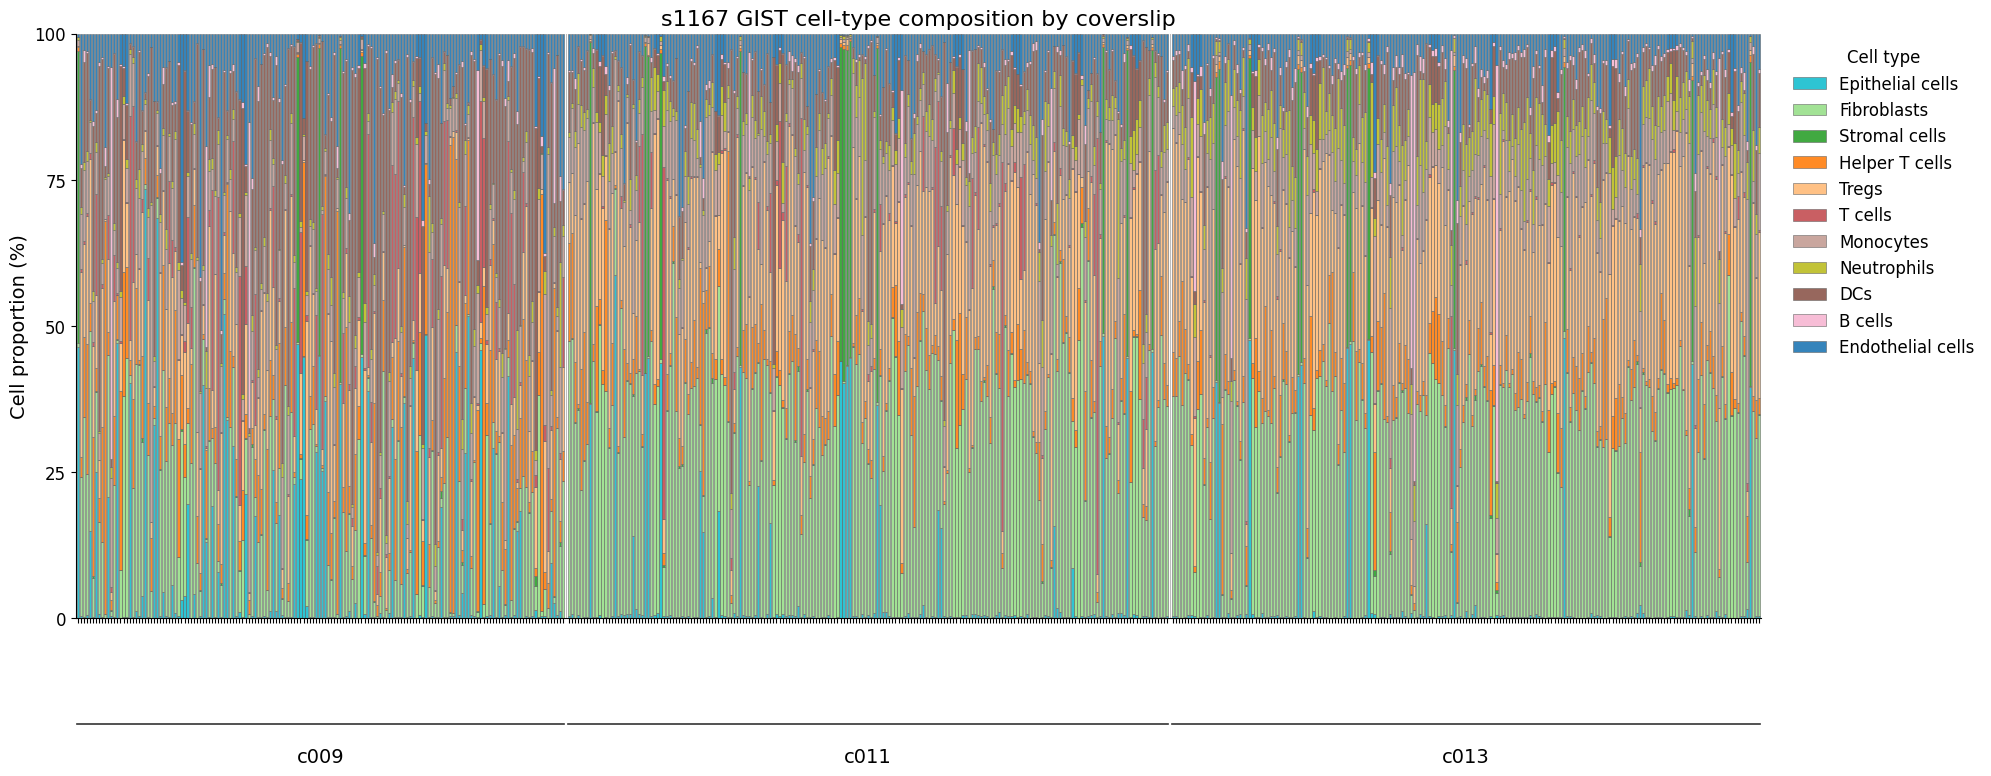

In [9]:

plot_celltype_proportions_stacked(
    gist_celltype_counts,
    rotation=90,
    xtick_fontsize=10,
    ytick_fontsize=12,
    label_fontsize=14,
    title_fontsize=16,
    legend_fontsize=12,
    legend_title_fontsize=12,
    celltype_order=list(GIST_CELLTYPES),
    celltype_colors=GIST_COLORS,
    condition_df=alignment_gist_df,
    condition="coverslip",
    sample_id_col="ACQUISITION_ID",
    condition_order=[c for c in GIST_COVERSLIP_ORDER if c in set(alignment_gist_df["coverslip"])],
    condition_gap=1.0,
    condition_line_y=-0.18,
    condition_label_y=-0.22,
    bottom_margin=0.22,
    figsize=(20, 8),
    title="s1167 GIST cell-type composition by coverslip",
    xlabel="",
    show_shading=True,
    shading_alpha=0.28,
    bar_width=0.72,
    bar_alpha=0.90,
    hide_xticklabels=True,
    # save_path=None,
    save_path=figure_save_path / "s1167_gist_celltype_proportions_stacked.pdf",
)


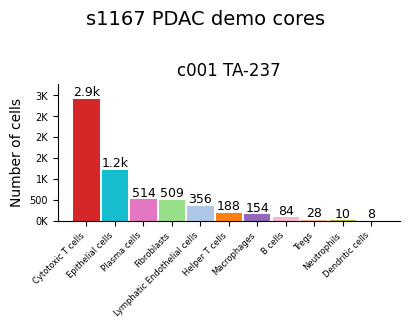

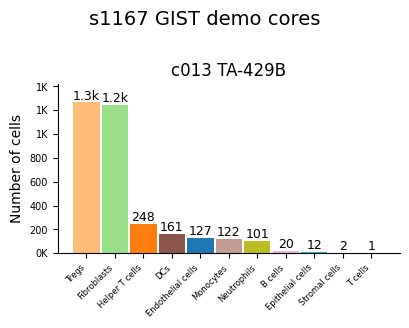

In [14]:
## Per-core bars: demo cores from pdac_cells_all / gist_cells_all
## (does not depend on the earlier cells_by_acq load cell)

PRIMARY_ACQ_ID = 'Charvill-94_c001_v001_r001_reg001'          # Pancreas TMA
PRIMARY_GIST_ACQ_ID = 'Charvill-94_c013_v001_r001_reg002'     # GIST TMA

pdac_demo_ids = [PRIMARY_ACQ_ID] + list(ACQ_IDS_ALSO_VIEW)
gist_demo_ids = [PRIMARY_GIST_ACQ_ID] + list(GIST_ACQ_IDS_ALSO_VIEW)
pdac_demo = {aid: pdac_cells_all[aid] for aid in pdac_demo_ids}
gist_demo = {aid: gist_cells_all[aid] for aid in gist_demo_ids}

plot_all_acq_celltype_distributions(
    pdac_demo,
    alignment_df,
    n_cols=2,
    celltype_filter=["Other"],
    celltype_colors=PDAC_COLORS,
    suptitle="s1167 PDAC demo cores",
    save_path=None,
    # save_path=figure_save_path / "s1167_pdac_demo_celltype_distribution.pdf",
)

plot_all_acq_celltype_distributions(
    gist_demo,
    alignment_gist_df,
    n_cols=2,
    celltype_filter=["Other"],
    celltype_colors=GIST_COLORS,
    suptitle="s1167 GIST demo cores",
    save_path=None,
    # save_path=figure_save_path / "s1167_gist_demo_celltype_distribution.pdf",
)


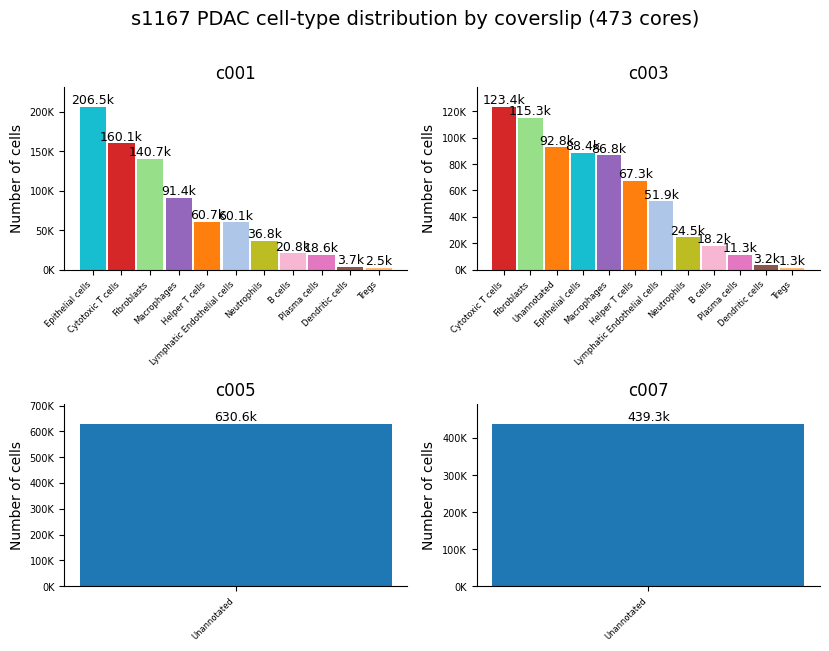

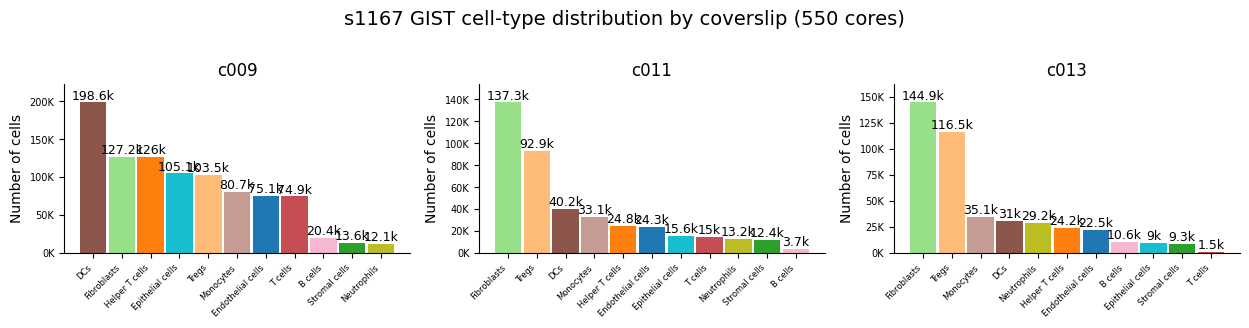

In [ ]:
## Coverslip-pooled (all annotated cores)
plot_all_acq_celltype_distributions(
    pool_cells_by_coverslip(pdac_cells_all),
    n_cols=2,
    celltype_filter=["Other"],
    celltype_colors=PDAC_COLORS,
    suptitle="s1167 PDAC cell-type distribution by coverslip (473 cores)",
    save_path=None,
    # save_path=figure_save_path / "s1167_pdac_coverslip_celltype_distribution.pdf",
)

plot_all_acq_celltype_distributions(
    pool_cells_by_coverslip(gist_cells_all),
    n_cols=3,
    celltype_filter=["Other"],
    celltype_colors=GIST_COLORS,
    suptitle="s1167 GIST cell-type distribution by coverslip (550 cores)",
    save_path=None,
    # save_path=figure_save_path / "s1167_gist_coverslip_celltype_distribution.pdf",
)


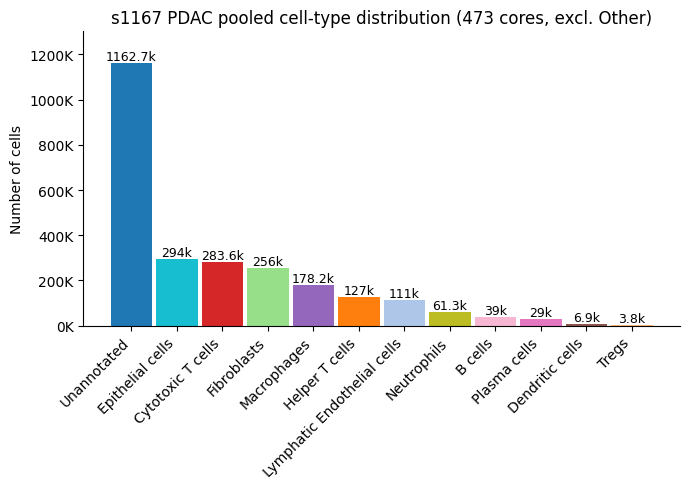

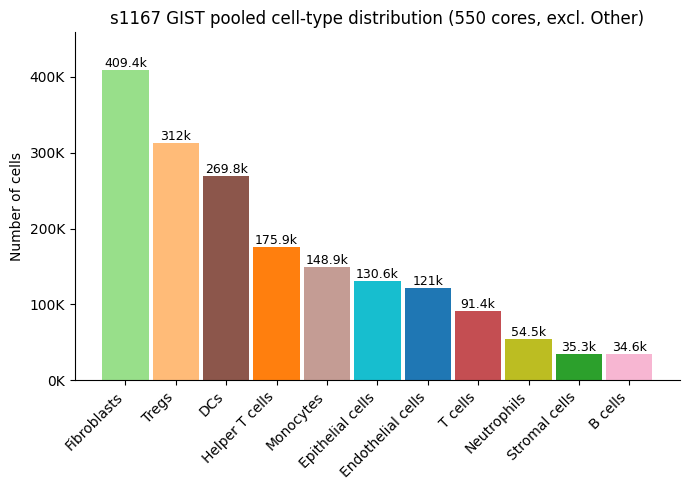

In [16]:
## Pooled distribution across all annotated cores (excl. Other)
plot_pooled_celltype_distribution(
    pdac_cells_all,
    celltype_filter=["Other"],
    celltype_colors=PDAC_COLORS,
    figsize=(7, 5),
    title="s1167 PDAC pooled cell-type distribution (473 cores, excl. Other)",
    save_path=None,
    # save_path=figure_save_path / "s1167_pdac_pooled_celltype_distribution.pdf",
)

plot_pooled_celltype_distribution(
    gist_cells_all,
    celltype_filter=["Other"],
    celltype_colors=GIST_COLORS,
    figsize=(7, 5),
    title="s1167 GIST pooled cell-type distribution (550 cores, excl. Other)",
    save_path=None,
    # save_path=figure_save_path / "s1167_gist_pooled_celltype_distribution.pdf",
)
